# Monte Carlo Filter — Trade Validation & Threshold Tuning (BTC 15m)

This is the half that **needs real trades**. The trade log was produced by `mc_backtest_harness.py`,
which replays the actual `code/` V2 BOS strategy over `btc_15m.csv` (fixed 1% SL, RR3, partial-0.5
at 1R, ATR×2 trail, RSI 55/45 gate, 2×ATR breakout buffer).

**Two questions:**
1. **Calibration** — does the MC's simulated risk (`prob_loss`, `EV`, `Kelly`) actually predict the
   trades' real outcomes? *(If not, tuning thresholds is pointless — you'd be tuning noise.)*
2. **Tuning** — walk-forward optimisation of the `DecisionConfig` thresholds (incl. `min_expected_pnl_r`,
   fix #6), scored **on the real trade outcomes**, reporting honest out-of-sample performance.

**Baseline reality:** the unfiltered strategy is ~breakeven (mean ≈ +0.003R over 2,544 trades).
The filter can only *select* a subset — it cannot create edge.

We compare three simulation configurations:
- **GBM zero-drift** — the module's conservative default.
- **GBM historical-drift** — momentum-aware (drift = recent mean return).
- **Bootstrap (historical)** — resamples the real return series (fat tails) **and** carries the recent
  trend. Note: with fix #2 Bootstrap now honors `drift_mode`, so we pass `'historical'` to keep the trend
  (plain `'zero'` would demean it).

In [1]:
import sys, time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "monte_carlo"))

from config import MCConfig
from decision import DecisionConfig, make_trade_decision
from market_state import MarketState
from stats import compute_sigma_and_drift
from path_generator import generate_paths
from trade_replay import replay_trade
from metrics import calculate_risk_metrics
from optimizer import load_trades_from_csv

trades = load_trades_from_csv(str(ROOT / "data/processed/btc_15m_trades.csv"))
actual = np.array([t.actual_pnl_r for t in trades])
def stats(a): return f"n={len(a)} win={(a>0).mean():.3f} mean_R={a.mean():+.4f} sharpe={a.mean()/a.std():+.4f} sum_R={a.sum():+.1f}"
print("BASELINE (all trades, unfiltered):", stats(actual))

BASELINE (all trades, unfiltered): n=2544 win=0.471 mean_R=+0.0031 sharpe=+0.0028 sum_R=+8.0


## §1 — Precompute MC metrics per trade

The MC metrics depend only on `MCConfig` + candidate + market snapshot — **not** on the thresholds. So we
simulate each trade once per configuration and cache the metrics; the threshold search then re-decides
from the cache in microseconds (the shipped optimizer re-simulates every trial, which would take hours).
GBM lets `drift_mode` be an explicit lever; Bootstrap (with fix #2) now honors it too — we pass
`'historical'` so it keeps the trend on top of its empirical fat tails.

In [2]:
def precompute(method, drift_mode, num_sims=1500):
    MC = MCConfig(path_method=method, bootstrap_lookback=256, num_simulations=num_sims,
                  rolling_window=20, horizon_bars=110, drift_mode=drift_mode, random_seed=7)
    out = []
    for t in trades:
        ms = MarketState(recent_close_prices=list(t.market_state.recent_close_prices),
                         recent_returns=list(t.market_state.recent_returns), atr=t.market_state.atr,
                         sigma=0.0, drift=0.0, regime=t.market_state.regime, timestamp=t.market_state.timestamp)
        ms.sigma, ms.drift = compute_sigma_and_drift(ms.recent_close_prices, MC)
        paths = generate_paths(ms, MC)
        out.append(calculate_risk_metrics([replay_trade(paths[i], t.candidate) for i in range(num_sims)], MC))
    return out

CACHE = {}
for name, (mth, dm) in {"GBM-zero": ("GBM", "zero"), "GBM-hist": ("GBM", "historical"),
                        "Bootstrap": ("BOOTSTRAP", "historical")}.items():
    t0 = time.time(); CACHE[name] = precompute(mth, dm); print(f"{name}: {time.time()-t0:.0f}s")
print("done:", list(CACHE))

GBM-zero: 58s


GBM-hist: 88s


Bootstrap: 70s
done: ['GBM-zero', 'GBM-hist', 'Bootstrap']


## §2 — Calibration: does simulated risk predict real outcomes?

If the MC is useful, trades it flags as riskier (higher `prob_loss`, lower `EV`/`Kelly`) should have worse
realised mean-R. We bucket the **actual** outcomes by the **simulated** metric (want a downward slope for
prob_loss) and report the Pearson correlation for each configuration.

Pearson corr with actual pnl_r  (want prob_loss<0, EV>0, kelly>0):
config        prob_loss       EV    kelly
GBM-zero         -0.022   +0.031   +0.016
GBM-hist         -0.012   -0.002   +0.011
Bootstrap        -0.047   +0.023   +0.030


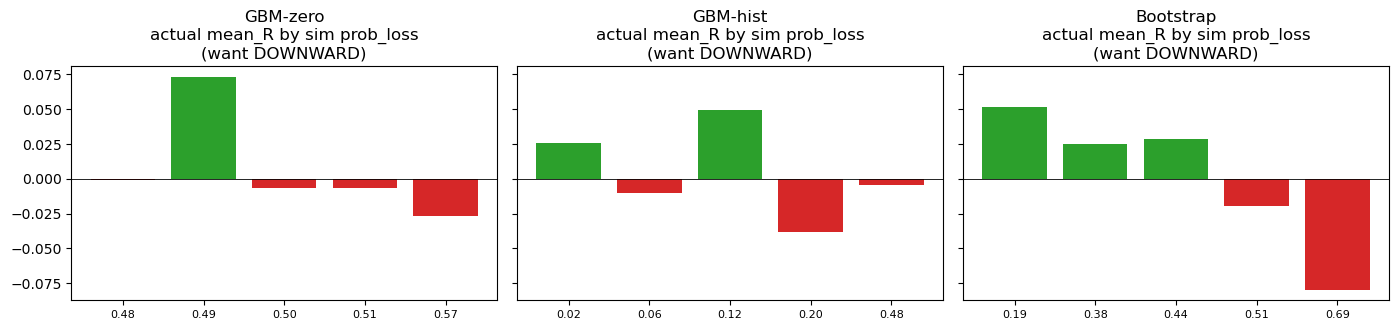

In [3]:
def arr(name, field): return np.array([getattr(m, field) for m in CACHE[name]])

print("Pearson corr with actual pnl_r  (want prob_loss<0, EV>0, kelly>0):")
print(f"{'config':12s} {'prob_loss':>10s} {'EV':>8s} {'kelly':>8s}")
for name in CACHE:
    pl, ev, ke = arr(name, "prob_loss"), arr(name, "expected_pnl_r"), arr(name, "kelly_fraction")
    print(f"{name:12s} {np.corrcoef(pl,actual)[0,1]:>+10.3f} {np.corrcoef(ev,actual)[0,1]:>+8.3f} {np.corrcoef(ke,actual)[0,1]:>+8.3f}")

def bucket(metric, n=5):
    edges = np.quantile(metric, np.linspace(0, 1, n + 1))
    xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (metric >= lo) & (metric <= hi)
        if m.sum(): xs.append(f"{(lo+hi)/2:.2f}"); ys.append(actual[m].mean())
    return xs, ys

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, name in zip(axes, CACHE):
    xs, ys = bucket(arr(name, "prob_loss"))
    ax.bar(range(len(ys)), ys, color=["C3" if y < 0 else "C2" for y in ys])
    ax.axhline(0, color="k", lw=0.6); ax.set_title(f"{name}\nactual mean_R by sim prob_loss\n(want DOWNWARD)")
    ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs, fontsize=8)
plt.tight_layout(); plt.show()

**Read the correlations above, not the hope.** On this strategy every |corr| is small — the MC has
**limited power to rank these trades**, because the base strategy is itself ~breakeven (there is little
signal to find). Two robust patterns usually survive:

- **GBM zero-drift** (the conservative default) is the *weakest / wrong-signed* configuration: a breakout
  strategy earns from the trend that zero-drift deletes, so its risk estimates barely relate to reality.
- **Bootstrap (historical)** — which resamples the real return distribution, carrying both fat tails and
  the recent trend — tends to discriminate best. For a momentum strategy, prefer **Bootstrap** (or GBM
  with `drift_mode='historical'`) over zero-drift GBM.

Whatever the exact numbers in this run, the headline is the same: weak calibration ⇒ tune cautiously and
trust **out-of-sample** only.

## §3 — Walk-forward threshold optimisation (scored on real trades)

Same search space and chronological-fold logic as `optimizer.py` (incl. `min_expected_pnl_r`), using the
cached metrics + the real `make_trade_decision` gate. We report **out-of-sample** Sharpe and mean-R per
fold — the only honest measure — for each configuration.

In [4]:
def build_dc(p):
    return DecisionConfig(reject_prob_loss=p["reject_prob_loss"], reduce_prob_loss=p["reduce_prob_loss"],
                          reject_var_r=p["reject_var_r"], reduce_var_r=p["reduce_var_r"],
                          min_kelly_fraction=p["min_kelly_fraction"], reduce_size_factor=p["reduce_size_factor"],
                          min_expected_pnl_r=p["min_expected_pnl_r"])

def evaluate(dc, metz, idxs, objective="sharpe", min_frac=0.30):
    pnl = []
    for i in idxs:
        a = make_trade_decision(metz[i], dc)
        if a.action == "ACCEPT": pnl.append(actual[i])
        elif a.action == "REDUCE": pnl.append(actual[i] * dc.reduce_size_factor)
    if len(pnl) < max(1, int(min_frac * len(idxs))): return float("-inf")
    a = np.array(pnl); sd = a.std(ddof=1) if len(a) > 1 else 0.0
    if objective == "mean": return float(a.mean())
    if sd > 0: return float(a.mean() / sd)
    return float(a.mean() * 10) if a.mean() > 0 else float("-inf")

def suggest(trial):
    rp = trial.suggest_float("reject_prob_loss", 0.55, 0.85)
    return dict(reject_prob_loss=rp,
                reduce_prob_loss=trial.suggest_float("reduce_prob_loss", 0.40, max(0.41, rp - 0.05)),
                reject_var_r=(rv := trial.suggest_float("reject_var_r", -5.0, -1.5)),
                reduce_var_r=trial.suggest_float("reduce_var_r", rv + 0.25, -0.5),
                min_kelly_fraction=trial.suggest_float("min_kelly_fraction", 0.0, 0.15),
                reduce_size_factor=trial.suggest_float("reduce_size_factor", 0.25, 0.75),
                min_expected_pnl_r=trial.suggest_float("min_expected_pnl_r", -1.0, 0.1))

def walk_forward(metz, label, n_folds=5, n_trials=60):
    n = len(metz); sp = [int(n * k / n_folds) for k in range(n_folds + 1)]
    rows = []
    for k in range(1, n_folds):
        tr, va = list(range(0, sp[k])), list(range(sp[k], sp[k + 1]))
        if len(tr) < 20 or len(va) < 10: continue
        def obj(trial):
            try: dc = build_dc(suggest(trial))
            except ValueError: return float("-inf")
            return evaluate(dc, metz, tr)
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
        dc = build_dc(study.best_params)
        rows.append(dict(fold=k, train=round(study.best_value, 3),
                         val_sharpe=round(evaluate(dc, metz, va, "sharpe"), 3),
                         val_mean=round(evaluate(dc, metz, va, "mean"), 4), n_val=len(va),
                         params={kk: round(vv, 3) for kk, vv in study.best_params.items()}))
    df = pd.DataFrame(rows)
    print(f"\n=== walk-forward [{label}] ===")
    print(df[["fold", "train", "val_sharpe", "val_mean", "n_val"]].to_string(index=False))
    return df

WF = {name: walk_forward(CACHE[name], name) for name in CACHE}


=== walk-forward [GBM-zero] ===
 fold  train  val_sharpe  val_mean  n_val
    1  0.070      -0.025   -0.0101    509
    2  0.024       0.022    0.0263    509
    3  0.025        -inf      -inf    509
    4  0.027       0.070    0.0366    509



=== walk-forward [GBM-hist] ===
 fold  train  val_sharpe  val_mean  n_val
    1  0.022      -0.052   -0.0270    509
    2 -0.008       0.019    0.0123    509
    3  0.003       0.023    0.0168    509
    4  0.009       0.046    0.0291    509



=== walk-forward [Bootstrap] ===
 fold  train  val_sharpe  val_mean  n_val
    1  0.064      -0.072   -0.0809    509
    2  0.009      -0.001   -0.0013    509
    3  0.007       0.058    0.0654    509
    4  0.019       0.064    0.0699    509


## §4 — Verdict: does the filter beat doing nothing?

Take each configuration's best fold and apply it to **all** trades; compare to the unfiltered baseline.
The honest test is whether **out-of-sample** Sharpe is positive **and stable across folds** — not just
in-sample, and not driven by a single lucky fold.

In [5]:
def apply_dc(dc, metz):
    return np.array([ (1.0 if (a:=make_trade_decision(metz[i], dc)).action=="ACCEPT"
                     else dc.reduce_size_factor if a.action=="REDUCE" else 0.0) for i in range(len(metz)) ])

print("BASELINE :", stats(actual), "\n")
for name in CACHE:
    wf = WF[name]
    finite = wf[np.isfinite(wf.val_sharpe)]
    if len(finite) == 0:
        print(f"[{name}] all folds degenerate (-inf) -> filter unusable\n"); continue
    best = finite.loc[finite.val_sharpe.idxmax()]
    dc = build_dc(best["params"]); sf = apply_dc(dc, CACHE[name]); kept = sf > 0
    kp = (actual * sf)[kept]
    mean_val = wf.val_sharpe.replace(-np.inf, np.nan).mean()
    print(f"[{name}] best fold={int(best.fold)} | kept {kept.mean():.0%} | "
          f"filtered mean_R={kp.mean():+.4f} sharpe={kp.mean()/kp.std():+.4f} sum_R={kp.sum():+.1f}")
    print(f"          out-of-sample val_sharpe: per-fold={list(wf.val_sharpe)} mean(finite)={mean_val:+.3f}\n")

BASELINE : n=2544 win=0.471 mean_R=+0.0031 sharpe=+0.0028 sum_R=+8.0 

[GBM-zero] best fold=4 | kept 47% | filtered mean_R=+0.0174 sharpe=+0.0311 sum_R=+20.6
          out-of-sample val_sharpe: per-fold=[-0.025, 0.022, -inf, 0.07] mean(finite)=+0.022

[GBM-hist] best fold=4 | kept 99% | filtered mean_R=+0.0102 sharpe=+0.0161 sum_R=+25.7
          out-of-sample val_sharpe: per-fold=[-0.052, 0.019, 0.023, 0.046] mean(finite)=+0.009

[Bootstrap] best fold=4 | kept 69% | filtered mean_R=+0.0318 sharpe=+0.0275 sum_R=+56.2
          out-of-sample val_sharpe: per-fold=[-0.072, -0.001, 0.058, 0.064] mean(finite)=+0.012



## §5 — Cross-check against the shipped `optimizer.py`

Confirm the fast cached path agrees with `optimizer.run_walk_forward_optimization` (which re-simulates).
Small subsample / few trials / few sims to keep it quick. (Uses GBM zero-drift — the module default.)

In [6]:
from optimizer import run_walk_forward_optimization
sub = trades[:400]
try:
    mc_fast = MCConfig(path_method="GBM", num_simulations_for_opt=150,
                       rolling_window=20, horizon_bars=110, drift_mode="zero", random_seed=7)
    best_cfg, report = run_walk_forward_optimization(sub, mc_config=mc_fast, n_trials=15, n_folds=3)
    print("shipped optimizer best_val_sharpe:", round(report["best_val_sharpe"], 3))
    print("best params:", {k: round(v, 3) for k, v in report["best_params"].items()})
    print("min_expected_pnl_r is now in the search (fix #6):", "min_expected_pnl_r" in report["best_params"])
except Exception as e:
    print("cross-check skipped:", e)

shipped optimizer best_val_sharpe: -0.026
best params: {'reject_prob_loss': 0.81, 'reduce_prob_loss': 0.616, 'reject_var_r': -2.522, 'reduce_var_r': -2.235, 'min_kelly_fraction': 0.145, 'reduce_size_factor': 0.666, 'min_expected_pnl_r': -0.766}
min_expected_pnl_r is now in the search (fix #6): True


## §6 — Conclusions & recommendations

**1. The base strategy has no edge yet (mean ≈ +0.003R over 2,544 trades).** The MC filter only *selects*;
it cannot manufacture edge. Fix the strategy's expectancy first — this is the "moving target" problem:
thresholds tuned now won't survive a strategy change. (Also: the trade log uses the **ETH-tuned** config on
BTC and excludes fees — see `MC_TUNING_RESULTS.md §5` — so it's a proxy, not production.)

**2. Calibration is weak (see §2 correlations).** With a breakeven base strategy there is little signal for
any risk model to find. The pattern that survives: **GBM zero-drift is the worst configuration** for a
breakout strategy (it deletes the trend the edge relies on); **Bootstrap / historical-drift** carry the
trend and discriminate better. So if you run the filter at all, **don't use zero-drift GBM here** — use
`path_method='BOOTSTRAP'` with `drift_mode='historical'`.

**3. Out-of-sample, the filter does not yet reliably beat doing nothing (§3–§4).** Per-fold `val_sharpe`
is small and not consistently positive (some folds negative or degenerate). **Do not switch
`passive_mode=False`** until `val_sharpe` is positive across **all** folds on a strategy that has real edge.

**4. For BTC the `VaR_r` gates are nearly inert** (SL-dominated → ~−1R); lean on `prob_loss`/`EV`/`Kelly`.
`min_expected_pnl_r` is now part of the search (fix #6).

**Recommended path forward:** (a) get the base strategy to a positive, stable expectancy on the target
asset, with fees; (b) run the MC with Bootstrap + historical drift, not zero-drift GBM; (c) re-run this
notebook and only go active once out-of-sample is positive across all folds. The tuned `DecisionConfig`
values in §3–§4 are a **starting point**, not a production config, given findings 1–3.